**Chapter 3 – Classification**

_This notebook contains all the sample code and solutions to the exercises in chapter 3._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-mlp/blob/main/03_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-mlp/blob/main/03_classification.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.10 or above:

In [41]:
import sys

assert sys.version_info >= (3, 10)

It also requires Scikit-Learn ≥ 1.6.1:

In [42]:
from packaging.version import Version
import sklearn

assert Version(sklearn.__version__) >= Version("1.6.1")

Just like in the previous chapter, let's define the default font sizes to make the figures prettier:

In [43]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# MNIST

In [44]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [45]:

print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [46]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [47]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [48]:
X.shape

(70000, 784)

In [49]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [50]:
y.shape

(70000,)

In [51]:
28 * 28

784

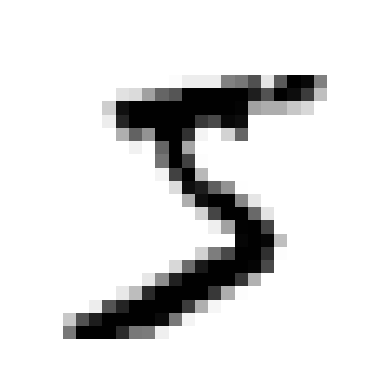

In [52]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)

plt.show()

In [53]:
y[0]

'5'

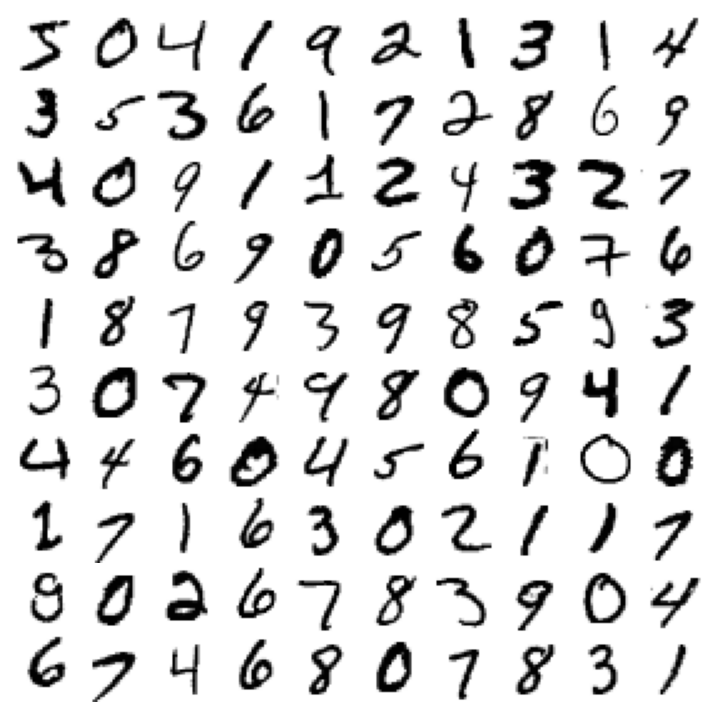

In [54]:

plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)

plt.show()

In [55]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Training a Binary Classifier

# **Problem 3**

# **3(a)**

In [56]:

import numpy as np
from sklearn.model_selection import train_test_split



#balance first, then split

# creating binary labels
# Prime digits
y_train_prime = ((y_train == '2') | (y_train == '3') | (y_train == '5') | (y_train == '7'))
# separating training data into prime and non-prime classes
X_train_true = X_train[(y_train == '2') | (y_train == '3') | (y_train == '5') | (y_train == '7')]
X_train_false = X_train[(y_train == '0') | (y_train == '1') | (y_train == '4') |
                        (y_train == '6') | (y_train == '8') | (y_train == '9')]
print("Original prime samples:", len(X_train_true))
print("Original non-prime samples:", len(X_train_false))
print()


Original prime samples: 23775
Original non-prime samples: 36225



In [57]:
# balancing the full training set first
count_true = len(X_train_true)
count_false = len(X_train_false)
target_count = max(count_true, count_false)

np.random.seed(42)

if count_true < count_false:
    idx_true = np.random.choice(count_true, size=target_count, replace=True)
    idx_false = np.random.choice(count_false, size=target_count, replace=False)
else:
    idx_true = np.random.choice(count_true, size=target_count, replace=False)
    idx_false = np.random.choice(count_false, size=target_count, replace=True)

X_true_bal_new = X_train_true[idx_true]
X_false_bal_new = X_train_false[idx_false]

y_true_bal_new = np.ones(len(X_true_bal_new), dtype=bool)
y_false_bal_new = np.zeros(len(X_false_bal_new), dtype=bool)

# Combining balanced data
X_bal_new = np.concatenate([X_true_bal_new, X_false_bal_new], axis=0)
y_bal_new = np.concatenate([y_true_bal_new, y_false_bal_new], axis=0)

# Shuffling
shuffle_idx = np.random.permutation(len(X_bal_new))
X_bal_new = X_bal_new[shuffle_idx]
y_bal_new = y_bal_new[shuffle_idx]

print("Balanced full dataset size:", len(X_bal_new))
print("Prime count after balancing:", np.sum(y_bal_new))
print("Non-prime count after balancing:", np.sum(y_bal_new == False))
print()


Balanced full dataset size: 72450
Prime count after balancing: 36225
Non-prime count after balancing: 36225



In [58]:
# Splitting into training and validation
X_tr_new, X_val_new, y_tr_new, y_val_new = train_test_split(
    X_bal_new, y_bal_new, test_size=0.2, random_state=42, stratify=y_bal_new
)

print("Training size:", len(X_tr_new))
print("Validation size:", len(X_val_new))
print()

Training size: 57960
Validation size: 14490



In [59]:
# Checking overlap between training and validation
train_set_new = set(map(tuple, X_tr_new))
val_set_new = set(map(tuple, X_val_new))

overlap_new = train_set_new.intersection(val_set_new)

print("Number of overlapping samples:", len(overlap_new))
print()

# Showing a few overlapping samples
overlap_list = list(overlap_new)

if len(overlap_list) > 0:
    print("Example overlapping samples:")
    for i, sample in enumerate(overlap_list[:5]):
        print(f"Overlap sample {i+1}:", sample[:10], "...")
else:
    print("No overlap found")

Number of overlapping samples: 4404

Example overlapping samples:
Overlap sample 1: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)) ...
Overlap sample 2: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)) ...
Overlap sample 3: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)) ...
Overlap sample 4: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)) ...
Overlap sample 5: (np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)) ...


# **3(b)**

In [60]:
import numpy as np


# 3(b) Balanced dataset by sampling the larger class
# with the number of samples given by the smaller class


# Creating binary labels

y_train_prime = ((y_train == '2') | (y_train == '3') | (y_train == '5') | (y_train == '7'))



# Separating the two classes
prime_samples = X_train[y_train_prime]
nonprime_samples = X_train[y_train_prime == False]

print("Original class counts:")
print("Prime count:", len(prime_samples))
print("Non-prime count:", len(nonprime_samples))
print()



Original class counts:
Prime count: 23775
Non-prime count: 36225



In [61]:
#Determining smaller and larger class
if len(prime_samples) < len(nonprime_samples):
    smaller_samples = prime_samples
    larger_samples = nonprime_samples
    smaller_labels = np.ones(len(smaller_samples), dtype=bool)
    larger_label_value = False
    print("Smaller class: Prime")
    print("Larger class: Non-prime")
else:
    smaller_samples = nonprime_samples
    larger_samples = prime_samples
    smaller_labels = np.zeros(len(smaller_samples), dtype=bool)
    larger_label_value = True
    print("Smaller class: Non-prime")
    print("Larger class: Prime")
print()



Smaller class: Prime
Larger class: Non-prime



In [62]:
# Randomly sampling from the larger class down to the smaller class size
target_count = len(smaller_samples)

np.random.seed(42)
sampled_idx = np.random.choice(len(larger_samples), size=target_count, replace=False)
sampled_larger_samples = larger_samples[sampled_idx]
sampled_larger_labels = np.full(target_count, larger_label_value, dtype=bool)

# Combining the smaller class and the sampled larger class
balanced_samples = np.concatenate([smaller_samples, sampled_larger_samples], axis=0)
balanced_labels = np.concatenate([smaller_labels, sampled_larger_labels], axis=0)

# Shuffling the balanced dataset
shuffle_idx = np.random.permutation(len(balanced_samples))
balanced_samples = balanced_samples[shuffle_idx]
balanced_labels = balanced_labels[shuffle_idx]

#first 10 elements to show random shuffle
print("First 10 samples of balanced dataset:")
print(balanced_samples[:10])
print()



First 10 samples of balanced dataset:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]



In [63]:
print("First 10 labels of balanced dataset:")
print(balanced_labels[:10])
print()



First 10 labels of balanced dataset:
[ True False  True  True  True  True  True False  True False]



In [64]:
# final class counts to show equality
print("Final balanced class counts:")
print("Prime count:", np.sum(balanced_labels == True))
print("Non-prime count:", np.sum(balanced_labels == False))
print("Total samples:", len(balanced_samples))

Final balanced class counts:
Prime count: 23775
Non-prime count: 23775
Total samples: 47550


# **3(c)**

In [65]:
from sklearn.model_selection import train_test_split


# 3(c) Training and Testing datasets (80/20 split)


# Splitting the balanced dataset
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    balanced_samples,
    balanced_labels,
    test_size=0.2,
    random_state=42,
    stratify=balanced_labels
)



In [66]:

# (ii) Printing number of elements

print("Number of elements:")
print("Training samples:", len(X_train_final))
print("Testing samples:", len(X_test_final))
print()

print("Training labels:", len(y_train_final))
print("Testing labels:", len(y_test_final))
print()

# balance
print("Training set class counts:")
print("Prime:", np.sum(y_train_final))
print("Non-prime:", np.sum(y_train_final == False))
print()

print("Testing set class counts:")
print("Prime:", np.sum(y_test_final))
print("Non-prime:", np.sum(y_test_final == False))
print()



Number of elements:
Training samples: 38040
Testing samples: 9510

Training labels: 38040
Testing labels: 9510

Training set class counts:
Prime: 19020
Non-prime: 19020

Testing set class counts:
Prime: 4755
Non-prime: 4755



In [67]:

# (iii)shapes

print("Shapes:")
print("X_train shape:", X_train_final.shape)
print("y_train shape:", y_train_final.shape)
print("X_test shape:", X_test_final.shape)
print("y_test shape:", y_test_final.shape)

Shapes:
X_train shape: (38040, 784)
y_train shape: (38040,)
X_test shape: (9510, 784)
y_test shape: (9510,)


# **3(d)**

In [68]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(loss='log_loss', random_state=42)
sgd_clf.fit(X_train_final, y_train_final)


SGDClassifier(loss='log_loss', random_state=42)

In [69]:
y_pred = sgd_clf.predict(X_test_final)
y_scores = sgd_clf.predict_proba(X_test_final)[:, 1]

In [70]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_metrics(y_true, y_pred, y_scores):
    """
    computing all required evaluation metrics
    """

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Precision
    precision = precision_score(y_true, y_pred)

    # Recall (Sensitivity)
    recall = recall_score(y_true, y_pred)

    # F1 Score
    f1 = f1_score(y_true, y_pred)

    # Specificity
    specificity = TN / (TN + FP)

    # AUC
    auc = roc_auc_score(y_true, y_scores)

    # results
    print("Confusion Matrix:\n", cm)
    print()

    print("Accuracy:", accuracy)

    print("Precision:", precision)


    print("Recall:", recall)


    print("F1 Score:", f1)

    print("Sensitivity:", recall)
    print("Specificity:", specificity)

    print("AUC:", auc)

    # Return values
    return {
        "confusion_matrix": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "sensitivity": recall,
        "specificity": specificity,
        "auc": auc
    }

In [71]:
results = evaluate_metrics(y_test_final, y_pred, y_scores)

Confusion Matrix:
 [[4025  730]
 [ 733 4022]]

Accuracy: 0.846161934805468
Precision: 0.8463804713804713
Recall: 0.8458464773922187
F1 Score: 0.8461133901335858
Sensitivity: 0.8458464773922187
Specificity: 0.8464773922187171
AUC: 0.8635286780974368


# **3(e) (Cross-validation over the training set)**

In [72]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# Metric function

def evaluate_metrics(y_true, y_pred, y_scores):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    sensitivity = recall
    specificity = TN / (TN + FP)
    auc = roc_auc_score(y_true, y_scores)

    return {
        "confusion_matrix": cm,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "auc": auc
    }


# Random Forest and 5-fold CV
# Using the balanced training set from 3(c)

rf_clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_results = []

fold_num = 1
for train_index, test_index in skf.split(X_train_final, y_train_final):

    X_train_fold = X_train_final[train_index]
    y_train_fold = y_train_final[train_index]

    X_test_fold = X_train_final[test_index]
    y_test_fold = y_train_final[test_index]

    # class counts to verify balance
    print(f"Fold {fold_num}")
    print("Training fold size:", len(X_train_fold))
    print("Validation fold size:", len(X_test_fold))
    print("Training fold - Prime:", np.sum(y_train_fold), "Non-prime:", np.sum(y_train_fold == False))
    print("Validation fold - Prime:", np.sum(y_test_fold), "Non-prime:", np.sum(y_test_fold == False))

    # Training classifier
    clf = clone(rf_clf)
    clf.fit(X_train_fold, y_train_fold)

    # Predict
    y_pred_fold = clf.predict(X_test_fold)
    y_scores_fold = clf.predict_proba(X_test_fold)[:, 1]

    # Computing metrics
    metrics = evaluate_metrics(y_test_fold, y_pred_fold, y_scores_fold)
    fold_results.append(metrics)

    print("Confusion Matrix:\n", metrics["confusion_matrix"])
    print("Accuracy:", metrics["accuracy"])
    print("Precision:", metrics["precision"])
    print("Recall:", metrics["recall"])
    print("F1 Score:", metrics["f1"])
    print("Sensitivity:", metrics["sensitivity"])
    print("Specificity:", metrics["specificity"])
    print("AUC:", metrics["auc"])
    print("-" * 50)

    fold_num += 1

Fold 1
Training fold size: 30432
Validation fold size: 7608
Training fold - Prime: 15216 Non-prime: 15216
Validation fold - Prime: 3804 Non-prime: 3804
Confusion Matrix:
 [[3736   68]
 [ 103 3701]]
Accuracy: 0.9775236593059937
Precision: 0.9819580790660652
Recall: 0.9729232386961093
F1 Score: 0.9774197808002113
Sensitivity: 0.9729232386961093
Specificity: 0.982124079915878
AUC: 0.9975247774493836
--------------------------------------------------
Fold 2
Training fold size: 30432
Validation fold size: 7608
Training fold - Prime: 15216 Non-prime: 15216
Validation fold - Prime: 3804 Non-prime: 3804
Confusion Matrix:
 [[3715   89]
 [  92 3712]]
Accuracy: 0.9762092534174553
Precision: 0.9765851091817943
Recall: 0.9758149316508938
F1 Score: 0.9761998685075608
Sensitivity: 0.9758149316508938
Specificity: 0.9766035751840169
AUC: 0.9965661664460786
--------------------------------------------------
Fold 3
Training fold size: 30432
Validation fold size: 7608
Training fold - Prime: 15216 Non-prim

**Find highest and lowest AUC folds**

In [73]:
# AUC values from all folds
auc_values = [result["auc"] for result in fold_results]

highest_auc_index = np.argmax(auc_values)
lowest_auc_index = np.argmin(auc_values)

print("Highest AUC fold:", highest_auc_index + 1)
print("Highest AUC value:", fold_results[highest_auc_index]["auc"])
print("Metrics for highest AUC fold:")
for key, value in fold_results[highest_auc_index].items():
    print(f"{key}:")
    print(value)
    print()

print("Lowest AUC fold:", lowest_auc_index + 1)
print("Lowest AUC value:", fold_results[lowest_auc_index]["auc"])
print("Metrics for lowest AUC fold:")
for key, value in fold_results[lowest_auc_index].items():
    print(f"{key}:")
    print(value)
    print()

Highest AUC fold: 3
Highest AUC value: 0.9977373490851956
Metrics for highest AUC fold:
confusion_matrix:
[[3734   70]
 [  83 3721]]

accuracy:
0.9798895899053628

precision:
0.9815352149828541

recall:
0.9781808622502629

f1:
0.979855167873601

sensitivity:
0.9781808622502629

specificity:
0.9815983175604627

auc:
0.9977373490851956

Lowest AUC fold: 5
Lowest AUC value: 0.9964635432733931
Metrics for lowest AUC fold:
confusion_matrix:
[[3728   76]
 [ 101 3703]]

accuracy:
0.9767350157728707

precision:
0.9798888594866367

recall:
0.9734490010515248

f1:
0.9766583146511935

sensitivity:
0.9734490010515248

specificity:
0.9800210304942166

auc:
0.9964635432733931



In [74]:
metric_names = ["accuracy", "precision", "recall", "f1", "sensitivity", "specificity", "auc"]

print("Percentage variation across folds:")
for metric in metric_names:
    values = [result[metric] for result in fold_results]
    min_val = np.min(values)
    max_val = np.max(values)

    if min_val != 0:
        percent_variation = ((max_val - min_val) / min_val) * 100
    else:
        percent_variation = 0.0

    print(f"{metric}:")
    print("  Min =", min_val)
    print("  Max =", max_val)
    print("  Percentage variation =", percent_variation, "%")
    print()

Percentage variation across folds:
accuracy:
  Min = 0.9759463722397477
  Max = 0.9798895899053628
  Percentage variation = 0.40404040404040154 %

precision:
  Min = 0.9765851091817943
  Max = 0.9819580790660652
  Percentage variation = 0.550179378505222 %

recall:
  Min = 0.9729232386961093
  Max = 0.9781808622502629
  Percentage variation = 0.5403944879762307 %

f1:
  Min = 0.9759178839320963
  Max = 0.979855167873601
  Percentage variation = 0.40344418381195224 %

sensitivity:
  Min = 0.9729232386961093
  Max = 0.9781808622502629
  Percentage variation = 0.5403944879762307 %

specificity:
  Min = 0.9766035751840169
  Max = 0.982124079915878
  Percentage variation = 0.5652759084791351 %

auc:
  Min = 0.9964635432733931
  Max = 0.9977373490851956
  Percentage variation = 0.12783265583585826 %



In [75]:
print("Average metrics across 5 folds:")
for metric in metric_names:
    values = [result[metric] for result in fold_results]
    print(f"{metric}: {np.mean(values)}")

Average metrics across 5 folds:
accuracy: 0.9772607781282862
precision: 0.9794084723063159
recall: 0.9750262881177708
f1: 0.9772102031529325
sensitivity: 0.9750262881177708
specificity: 0.9794952681388013
auc: 0.9970198092439084


# **3(f) (parameter optimization using GridSearchCV(.) and final results on the test set)**

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# Defining model
rf = RandomForestClassifier(random_state=42)

# Defining hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30]
}

# Setting up GridSearchCV using AUC
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# GridSearchCV on the balanced training set
grid_search.fit(X_train_final, y_train_final)

# Best parameters and best validation AUC
print("Best parameters:", grid_search.best_params_)
print("Best validation AUC:", grid_search.best_score_)

# Evaluation on final test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test_final)
y_scores = best_rf.predict_proba(X_test_final)[:, 1]

test_auc = roc_auc_score(y_test_final, y_scores)
print("Test AUC:", test_auc)

# All final test metrics
results = evaluate_metrics(y_test_final, y_pred, y_scores)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': None, 'n_estimators': 500}
Best validation AUC: 0.9974272128734931
Test AUC: 0.9977117672359938


# **Problem 4**

Unique mapped train labels: ['A' 'B' 'C']
Unique mapped test labels: ['A' 'B' 'C']

Confusion Matrix:
[[2716  225  206]
 [ 122 2513  249]
 [ 141  763 3065]]



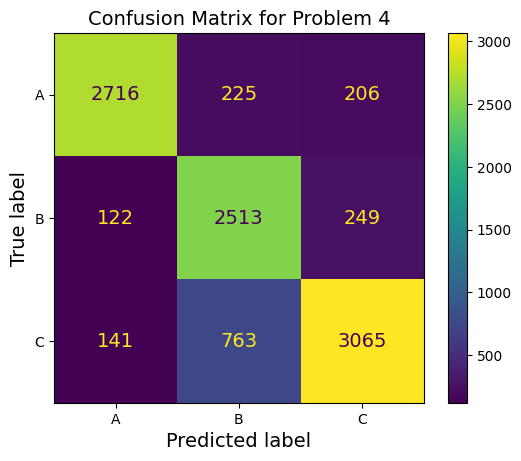

Accuracy: 0.8294

Number of correct predictions: 8294
Number of incorrect predictions: 1706



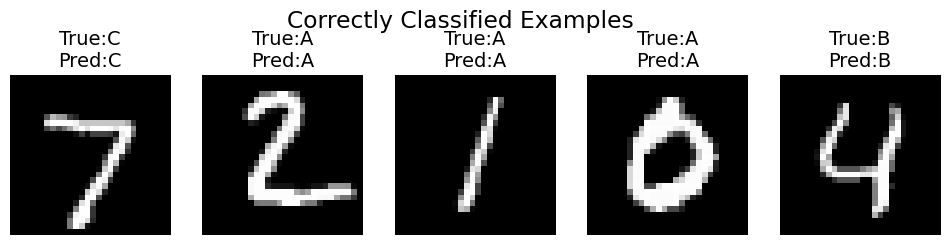

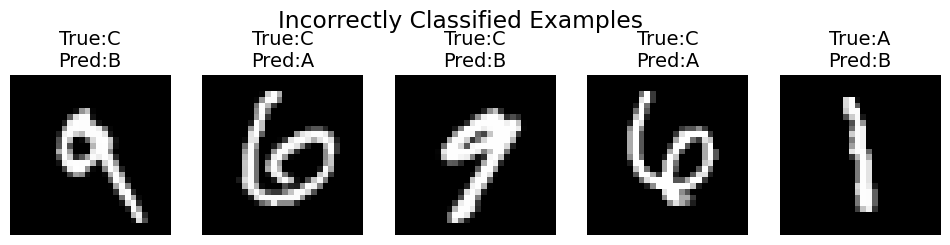

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay


# Problem 4: Multiclass classifier on MNIST
# Class A: 0, 1, 2
# Class B: 3, 4, 5
# Class C: 6, 7, 8, 9


# Recreate the MNIST train/test split directly from the original mnist object
X_mnist = mnist.data
y_mnist = mnist.target

X_train_mnist, X_test_mnist = X_mnist[:60000], X_mnist[60000:]
y_train_mnist, y_test_mnist = y_mnist[:60000], y_mnist[60000:]


# Map digits to A / B / C

def map_to_ABC(y):
    y_new = []

    for val in y:
        if val in ['0', '1', '2']:
            y_new.append('A')
        elif val in ['3', '4', '5']:
            y_new.append('B')
        elif val in ['6', '7', '8', '9']:
            y_new.append('C')
        else:
            raise ValueError(f"Unexpected label found: {val}")

    return np.array(y_new)

y_train_ABC = map_to_ABC(y_train_mnist)
y_test_ABC = map_to_ABC(y_test_mnist)

print("Unique mapped train labels:", np.unique(y_train_ABC))
print("Unique mapped test labels:", np.unique(y_test_ABC))
print()


# Training SGD multiclass classifier

sgd_clf_multi = SGDClassifier(random_state=42)
sgd_clf_multi.fit(X_train_mnist, y_train_ABC)


# Prediction on test set

y_test_pred_ABC = sgd_clf_multi.predict(X_test_mnist)


# Confusion matrix

cm_multi = confusion_matrix(y_test_ABC, y_test_pred_ABC, labels=['A', 'B', 'C'])
print("Confusion Matrix:")
print(cm_multi)
print()
disp = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=['A', 'B', 'C'])
disp.plot()
plt.title("Confusion Matrix for Problem 4")
plt.show()


# Accuracy

acc_multi = accuracy_score(y_test_ABC, y_test_pred_ABC)
print("Accuracy:", acc_multi)
print()


# correct and incorrect examples

correct_idx = np.where(y_test_ABC == y_test_pred_ABC)[0]
incorrect_idx = np.where(y_test_ABC != y_test_pred_ABC)[0]

print("Number of correct predictions:", len(correct_idx))
print("Number of incorrect predictions:", len(incorrect_idx))
print()


# correctly classified examples

plt.figure(figsize=(12, 3))
for i, idx in enumerate(correct_idx[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_mnist[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True:{y_test_ABC[idx]}\nPred:{y_test_pred_ABC[idx]}")
    plt.axis('off')
plt.suptitle("Correctly Classified Examples")
plt.show()


# incorrectly classified examples

plt.figure(figsize=(12, 3))
for i, idx in enumerate(incorrect_idx[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_mnist[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True:{y_test_ABC[idx]}\nPred:{y_test_pred_ABC[idx]}")
    plt.axis('off')
plt.suptitle("Incorrectly Classified Examples")
plt.show()

In [38]:

#pairwise class splits to match professor discussion
# A vs B, A vs C, B vs C


# A vs B
mask_AB = (y_train_ABC == 'A') | (y_train_ABC == 'B')
X_AB = X_train_mnist[mask_AB]
y_AB = y_train_ABC[mask_AB]

clf_AB = SGDClassifier(random_state=42)
clf_AB.fit(X_AB, y_AB)

print("A vs B training samples:", len(y_AB))
print("Unique labels in A vs B:", np.unique(y_AB))
print()

# A vs C
mask_AC = (y_train_ABC == 'A') | (y_train_ABC == 'C')
X_AC = X_train_mnist[mask_AC]
y_AC = y_train_ABC[mask_AC]

clf_AC = SGDClassifier(random_state=42)
clf_AC.fit(X_AC, y_AC)

print("A vs C training samples:", len(y_AC))
print("Unique labels in A vs C:", np.unique(y_AC))
print()

# B vs C
mask_BC = (y_train_ABC == 'B') | (y_train_ABC == 'C')
X_BC = X_train_mnist[mask_BC]
y_BC = y_train_ABC[mask_BC]

clf_BC = SGDClassifier(random_state=42)
clf_BC.fit(X_BC, y_BC)

print("B vs C training samples:", len(y_BC))
print("Unique labels in B vs C:", np.unique(y_BC))
print()

A vs B training samples: 36017
Unique labels in A vs B: ['A' 'B']

A vs C training samples: 42606
Unique labels in A vs C: ['A' 'C']

B vs C training samples: 41377
Unique labels in B vs C: ['B' 'C']



# **Problem 5**

(i) Maximize TPR subject to FPR <= 0.1
Threshold: 0.268
FPR: 0.09905362776025237
TPR: 0.9981072555205047

(ii) Minimize FPR subject to TPR >= 0.9
Threshold: 0.722
FPR: 0.004206098843322818
TPR: 0.9007360672975815

(iii) Balanced approach
Threshold: 0.514
FPR: 0.017665615141955835
TPR: 0.9747634069400631
Objective: -0.9394321766561514



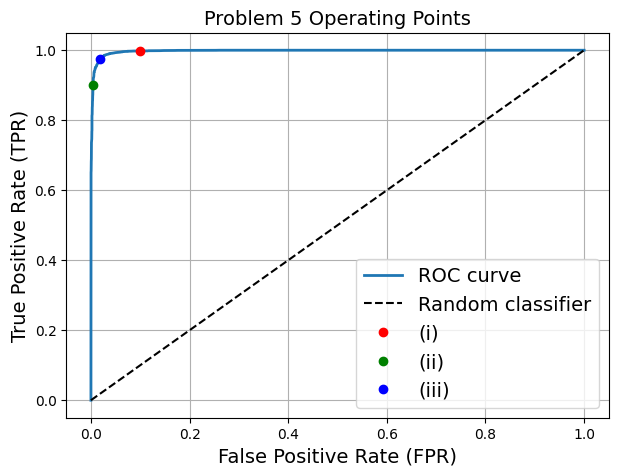

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC on test set
fpr, tpr, thresholds = roc_curve(y_test_final, y_scores)


# (i) Maximize TPR subject to FPR <= 0.1

best_tpr_i = -1
best_fpr_i = None
best_thr_i = None

for i in range(len(thresholds)):
    if fpr[i] <= 0.1:
        if tpr[i] > best_tpr_i:
            best_tpr_i = tpr[i]
            best_fpr_i = fpr[i]
            best_thr_i = thresholds[i]

print("(i) Maximize TPR subject to FPR <= 0.1")
print("Threshold:", best_thr_i)
print("FPR:", best_fpr_i)
print("TPR:", best_tpr_i)
print()


# (ii) Minimize FPR subject to TPR >= 0.9

best_fpr_ii = float("inf")
best_tpr_ii = None
best_thr_ii = None

for i in range(len(thresholds)):
    if tpr[i] >= 0.9:
        if fpr[i] < best_fpr_ii:
            best_fpr_ii = fpr[i]
            best_tpr_ii = tpr[i]
            best_thr_ii = thresholds[i]

print("(ii) Minimize FPR subject to TPR >= 0.9")
print("Threshold:", best_thr_ii)
print("FPR:", best_fpr_ii)
print("TPR:", best_tpr_ii)
print()


# (iii) Balanced approach
# minimize -TPR + 2*FPR
# subject to TPR >= 0.8 and FPR <= 0.1

best_obj_iii = float("inf")
best_fpr_iii = None
best_tpr_iii = None
best_thr_iii = None

for i in range(len(thresholds)):
    if (tpr[i] >= 0.8) and (fpr[i] <= 0.1):
        obj = -tpr[i] + 2 * fpr[i]
        if obj < best_obj_iii:
            best_obj_iii = obj
            best_fpr_iii = fpr[i]
            best_tpr_iii = tpr[i]
            best_thr_iii = thresholds[i]

print("(iii) Balanced approach")
if best_thr_iii is not None:
    print("Threshold:", best_thr_iii)
    print("FPR:", best_fpr_iii)
    print("TPR:", best_tpr_iii)
    print("Objective:", best_obj_iii)
else:
    print("No feasible threshold found for the constraints TPR >= 0.8 and FPR <= 0.1")
print()


# ROC plotting at selected points

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")

if best_fpr_i is not None and best_tpr_i is not None:
    plt.plot(best_fpr_i, best_tpr_i, 'ro', label="(i)")

if best_fpr_ii is not None and best_tpr_ii is not None:
    plt.plot(best_fpr_ii, best_tpr_ii, 'go', label="(ii)")

if best_fpr_iii is not None and best_tpr_iii is not None:
    plt.plot(best_fpr_iii, best_tpr_iii, 'bo', label="(iii)")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Problem 5 Operating Points")
plt.legend(loc="lower right")
plt.grid()
plt.show()